In [2]:
import numpy as np
from datetime import datetime 

import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
import seaborn as sns
sns.set_theme()
import pandas as pd
pd.set_option('display.precision', 2)

from pathlib import Path

import math
# import gcm

## 1. Load data

In [19]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
slc = xr.open_zarr(data_dir + 'stacks/slc_box_south_1x1')
print(slc)
# rmnp = xr.open_zarr(data_dir + 'stacks/rmnp_box_swe')

<xarray.Dataset> Size: 7MB
Dimensions:          (y: 206, x: 276, flight_id: 1, pol: 4, pair: 6)
Coordinates:
  * y                (y) float64 2kB 40.6 40.6 40.6 40.6 ... 40.52 40.52 40.52
  * x                (x) float64 2kB -111.7 -111.7 -111.7 ... -111.6 -111.6
  * flight_id        (flight_id) <U5 20B '27129'
  * pol              (pol) <U2 32B 'VV' 'HH' 'VH' 'HV'
  * pair             (pair) <U13 312B '200213_200221' ... '210316_210322'
    band             int64 8B ...
    spatial_ref      int64 8B ...
Data variables:
    canopy_2019      (y, x) float32 227kB dask.array<chunksize=(206, 276), meta=np.ndarray>
    coherence        (flight_id, pol, pair, y, x) float32 5MB dask.array<chunksize=(1, 2, 3, 103, 138), meta=np.ndarray>
    cover_2019       (y, x) float64 455kB dask.array<chunksize=(206, 276), meta=np.ndarray>
    elevation        (y, x) float32 227kB dask.array<chunksize=(206, 276), meta=np.ndarray>
    incidence_angle  (flight_id, y, x) float64 455kB dask.array<chunksize=(1,

## 2. Filter data

Filter by: 
- Incidence angle < 80 degrees 
- Canopy cover < 30% 
- Elevation > the 20th quantile


In [4]:
inc_cutoff = 80
canopy_cutoff = 30
elev_quant = 60

In [5]:
def filter_data(data) : 
    single_year_pairs = [
        p for p in data.coords['pair'].values 
        if p[:2] == p[7:9]
    ]

    print(f'Filtering for {len(single_year_pairs)} single-year pairs.')
    data = data.sel(pair=single_year_pairs)

    print(f'Trimming to DEM.')
    data = data.where(data['elevation'].notnull())

    print(f'Filtering inc angle > {inc_cutoff}, canopy cover > {canopy_cutoff}, elev top {elev_quant}%.')
    condition = (data['incidence_angle'] < inc_cutoff) & \
                (data['canopy_2019'] < canopy_cutoff) & \
                (data['elevation'] > data['elevation'].quantile((100-elev_quant)/100))

    data = data.where(condition)

    return data
    

In [24]:
# rmnp_good = filter_data(rmnp)
slc_good = filter_data(slc.sel(flight_id='27129'))
print(slc_good)

Filtering for 6 single-year pairs.
Trimming to DEM.
Filtering inc angle > 80, canopy cover > 30, elev top 60%.
<xarray.Dataset> Size: 7MB
Dimensions:          (y: 206, x: 276, pol: 4, pair: 6)
Coordinates:
  * y                (y) float64 2kB 40.6 40.6 40.6 40.6 ... 40.52 40.52 40.52
  * x                (x) float64 2kB -111.7 -111.7 -111.7 ... -111.6 -111.6
  * pol              (pol) <U2 32B 'VV' 'HH' 'VH' 'HV'
  * pair             (pair) <U13 312B '200213_200221' ... '210316_210322'
    band             int64 8B ...
    flight_id        <U5 20B '27129'
    spatial_ref      int64 8B ...
    quantile         float64 8B 0.4
Data variables:
    canopy_2019      (y, x) float32 227kB dask.array<chunksize=(103, 276), meta=np.ndarray>
    coherence        (pol, pair, y, x) float32 5MB dask.array<chunksize=(2, 3, 103, 138), meta=np.ndarray>
    cover_2019       (y, x) float64 455kB dask.array<chunksize=(103, 276), meta=np.ndarray>
    elevation        (y, x) float32 227kB dask.array<chunksize

Show filters

In [25]:
filters_to_plot = slc 

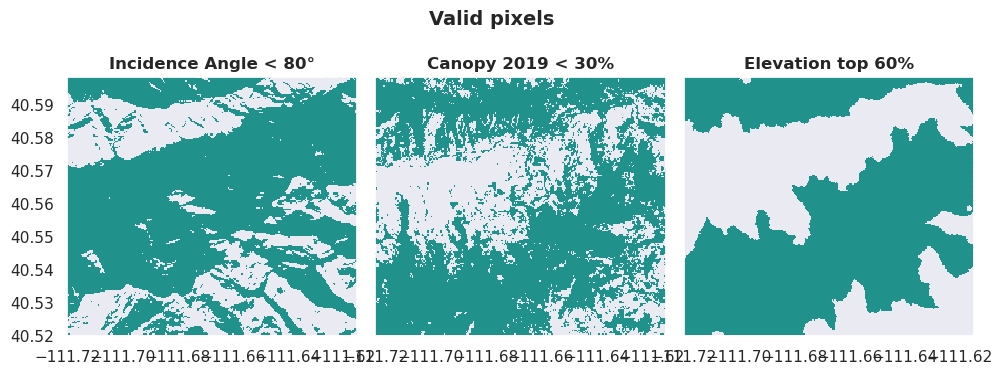

In [26]:
# show filters 

conditions = {
    f"Incidence Angle < {inc_cutoff}°": filters_to_plot['incidence_angle'] < inc_cutoff,
    f"Canopy 2019 < {canopy_cutoff}%": filters_to_plot['canopy_2019'] < canopy_cutoff,
    # "Cover 2019 (Shrubs)": (data['cover_2019'] > 50) & (data['cover_2019'] < 80),
    f"Elevation top {elev_quant}%": filters_to_plot['elevation'] > filters_to_plot['elevation'].quantile((100-elev_quant)/100)
}

# 2. Set up a 2x2 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)
axes = axes.ravel()  # Flatten the 2x2 grid into a 1D array for easy looping

# 3. Loop through and plot each isolated condition
for i, (title, cond) in enumerate(conditions.items()):
    ax = axes[i]
    
    # Use .where() to keep data where True, and set where False to NaN.
    # We can just plot 'cond' itself, or apply it to a variable like 'coherence'
    # if you want to see the underlying data values that passed.
    masked_slice = cond.where(cond) 
    
    # Squeeze out any extra dimensions (like band/time) if they exist
    masked_slice = masked_slice.squeeze()
    
    # Plot using xarray's native plotting wrapper, matching your style
    masked_slice.plot(
        ax=ax,
        cmap='viridis',     # Viridis will color the 'True' pixels
        add_colorbar=False
    )
    
    # Clean up the subplot
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')  # Remove repetitive x/y labels if sharing axes
    ax.set_ylabel('')

# Add a main title and clean up layout
plt.suptitle("Valid pixels", 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 3. Filter by cross-pol coherence

In [28]:
xpol_cutoff = 0.9 

to_filter = slc_good 
print(to_filter)

<xarray.Dataset> Size: 7MB
Dimensions:          (y: 206, x: 276, pol: 4, pair: 6)
Coordinates:
  * y                (y) float64 2kB 40.6 40.6 40.6 40.6 ... 40.52 40.52 40.52
  * x                (x) float64 2kB -111.7 -111.7 -111.7 ... -111.6 -111.6
  * pol              (pol) <U2 32B 'VV' 'HH' 'VH' 'HV'
  * pair             (pair) <U13 312B '200213_200221' ... '210316_210322'
    band             int64 8B ...
    flight_id        <U5 20B '27129'
    spatial_ref      int64 8B ...
    quantile         float64 8B 0.4
Data variables:
    canopy_2019      (y, x) float32 227kB dask.array<chunksize=(103, 276), meta=np.ndarray>
    coherence        (pol, pair, y, x) float32 5MB dask.array<chunksize=(2, 3, 103, 138), meta=np.ndarray>
    cover_2019       (y, x) float64 455kB dask.array<chunksize=(103, 276), meta=np.ndarray>
    elevation        (y, x) float32 227kB dask.array<chunksize=(103, 276), meta=np.ndarray>
    incidence_angle  (y, x) float64 455kB dask.array<chunksize=(103, 276), meta=n

In [34]:
coh_dir = Path(data_dir + "/uavsar_cohs_cropped/stlake/27129/")
print(coh_dir)

# Find all cross-pol files
file_paths = list(coh_dir.glob("*_crosspol_coh.tif"))
print(file_paths)

crosspol_lists = []
dates = []

for path in file_paths:
    # Example filename: stlake_27129_200131_HV-VH_s1_w5_crosspol_coh.tif
    # Split by underscore and grab the date string (index 2)
    date_str = path.name.split('_')[2] 
    
    # Open the TIFF and drop the single 'band' dimension to keep it 2D (y, x)
    da = rio.open_rasterio(path).squeeze('band', drop=True)
    
    crosspol_lists.append(da)
    dates.append(date_str)

# Combine all individual flight dates into a single DataArray
da_crosspol = xr.concat(crosspol_lists, dim='date')
da_crosspol = da_crosspol.rio.write_crs('EPSG:4326')
da_crosspol['date'] = dates
print(da_crosspol)

/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129
[PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_210310_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_200221_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_210210_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_210223_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_210316_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_210203_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropp

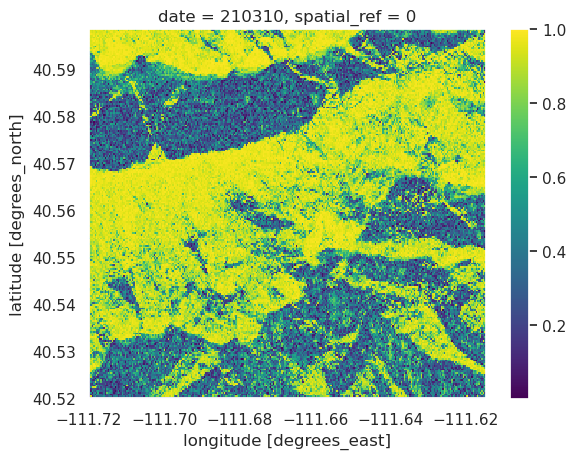

In [35]:
da_crosspol = da_crosspol.rio.reproject_match(to_filter)
da_crosspol.sel(date='210310').plot()

<xarray.DataArray (pair: 6, y: 206, x: 276)> Size: 1MB
array([[[0.97544146, 0.9634918 , 0.910671  , ..., 0.45975858,
         0.49258217, 0.11704855],
        [0.9601443 , 0.95953   , 0.9031932 , ..., 0.6194095 ,
         0.845488  , 0.55219316],
        [0.9574241 , 0.95950633, 0.98507327, ..., 0.3673808 ,
         0.29822084, 0.94837224],
        ...,
        [0.6838346 , 0.166853  , 0.33995968, ..., 0.7286462 ,
         0.3672838 , 0.36784467],
        [0.36730722, 0.7924596 , 0.4415812 , ..., 0.15671012,
         0.4701618 , 0.04714717],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[0.98605144, 0.98614085, 0.9630942 , ..., 0.70733064,
         0.6348027 , 0.26916984],
        [0.945261  , 0.9737039 , 0.96488136, ..., 0.35938412,
         0.728284  , 0.7456948 ],
        [0.9856018 , 0.9860906 , 0.98890454, ..., 0.39322782,
         0.03497778, 0.8666918 ],
...
        [0.15150484, 0.14242767, 0.2747816 , ..., 0.7964766 ,


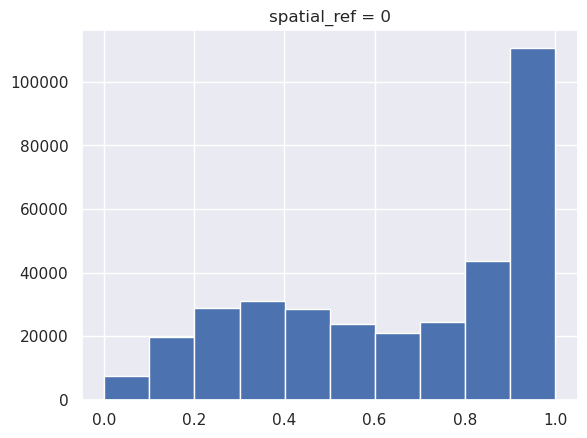

In [37]:
pair_names = to_filter['pair'].values
dates_1 = [p.split('_')[0] for p in pair_names]
dates_2 = [p.split('_')[1] for p in pair_names]

# 2. Use xarray's advanced indexing to pull the cross-pol data for all date1s and date2s.
# This creates 3D arrays (pair, y, x) matching your interferometric structure.
crosspol_date1 = da_crosspol.sel(date=xr.DataArray(dates_1, dims='pair', coords={'pair': pair_names}))
print(crosspol_date1)
crosspol_date2 = da_crosspol.sel(date=xr.DataArray(dates_2, dims='pair', coords={'pair': pair_names}))
crosspol_date2.plot()

# 3. Create a boolean mask where BOTH flights must be >= threshold
# (Pixels fail if either flight falls below the threshold)
crosspol_mask = (crosspol_date1 >= xpol_cutoff) & (crosspol_date2 >= xpol_cutoff)

# 4. Filter your existing dataset using the mask
filtered = to_filter.where(crosspol_mask)

## 3. Visualize

In [38]:
to_plot = filtered 
to_plot

<xarray.Dataset> Size: 14MB
Dimensions:          (y: 206, x: 276, pair: 6, pol: 4)
Coordinates:
  * y                (y) float64 2kB 40.6 40.6 40.6 40.6 ... 40.52 40.52 40.52
  * x                (x) float64 2kB -111.7 -111.7 -111.7 ... -111.6 -111.6
  * pair             (pair) <U13 312B '200213_200221' ... '210316_210322'
  * pol              (pol) <U2 32B 'VV' 'HH' 'VH' 'HV'
    band             int64 8B ...
    flight_id        <U5 20B '27129'
    spatial_ref      int64 8B 0
    quantile         float64 8B 0.4
Data variables:
    canopy_2019      (y, x, pair) float32 1MB dask.array<chunksize=(103, 276, 6), meta=np.ndarray>
    coherence        (pol, pair, y, x) float32 5MB dask.array<chunksize=(2, 3, 103, 138), meta=np.ndarray>
    cover_2019       (y, x, pair) float64 3MB dask.array<chunksize=(103, 276, 6), meta=np.ndarray>
    elevation        (y, x, pair) float32 1MB dask.array<chunksize=(103, 276, 6), meta=np.ndarray>
    incidence_angle  (y, x, pair) float64 3MB dask.array<chunksize=(103, 276, 6), meta=np.ndarray>

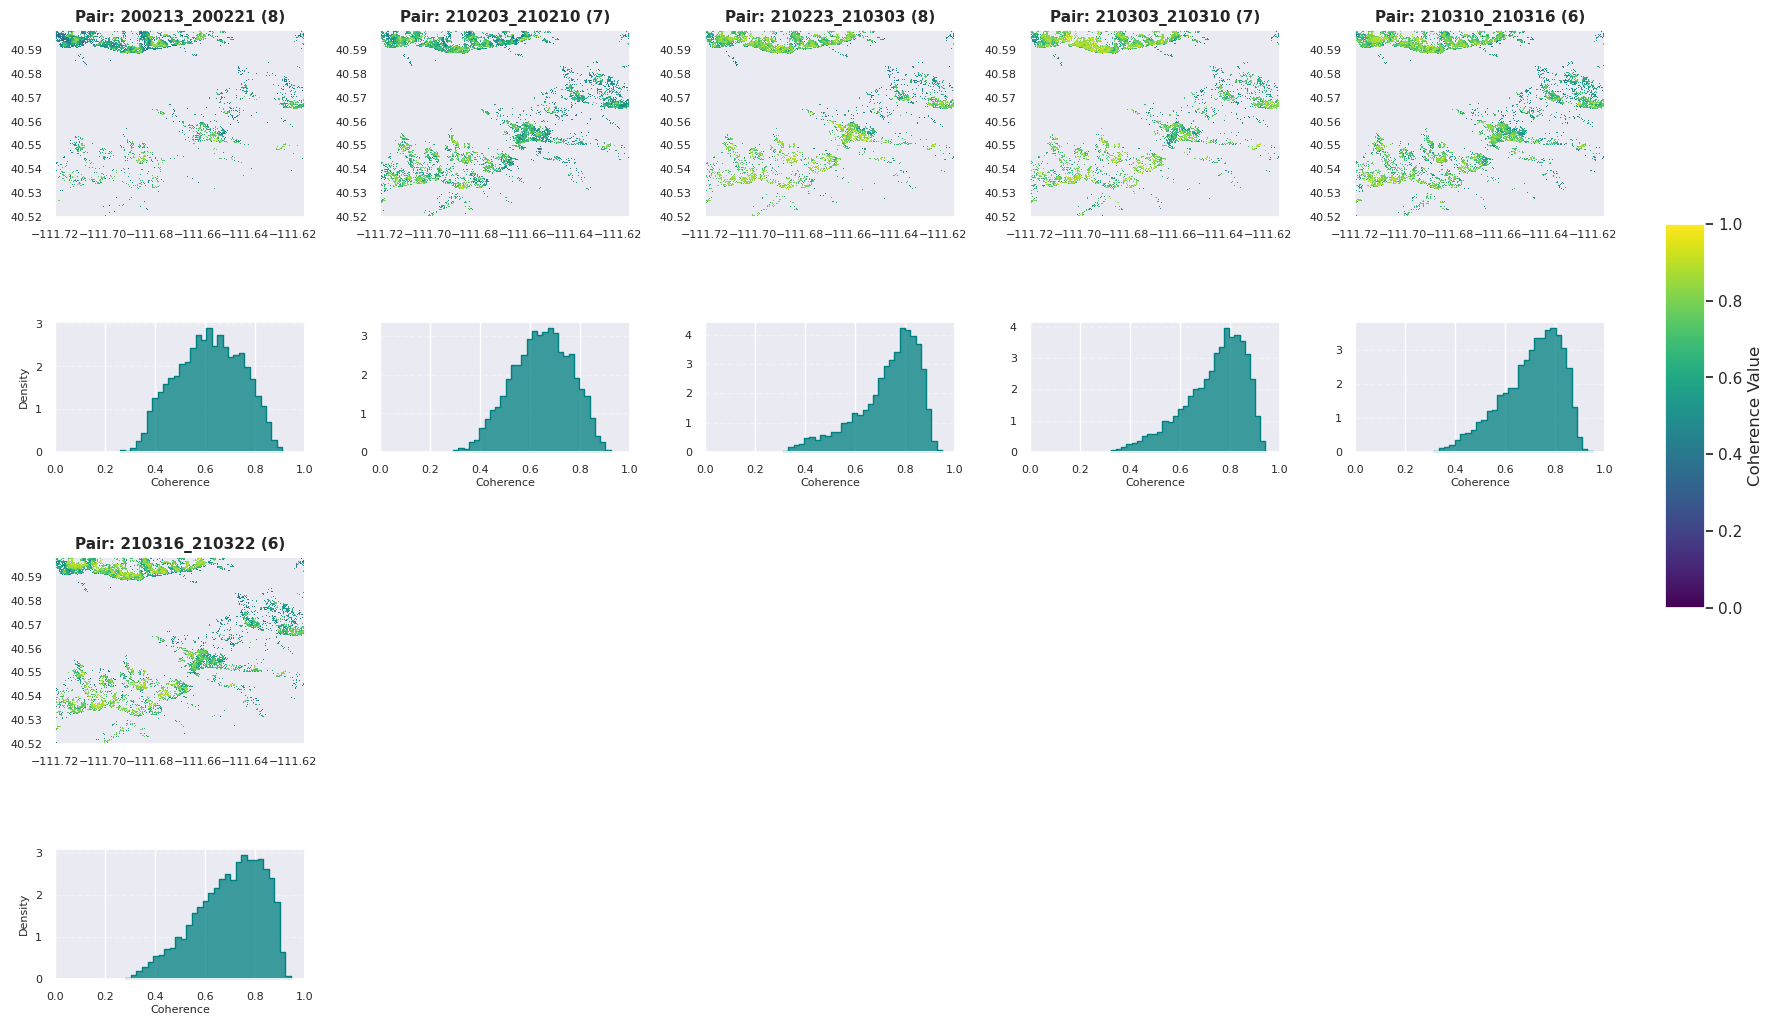

In [39]:
# plot 
ds_sorted = to_plot.sortby('pair')
pairs = ds_sorted.pair.values
num_pairs = len(pairs)

# 2. Configure the 5-column grid layout
ncols = 5
num_groups = (num_pairs + ncols - 1) // ncols
nrows = num_groups * 2 

# --- THE FIX: Create alternating height ratios (Map = 2, Hist = 1) ---
# For 3 groups (6 rows), this generates: [2, 1, 2, 1, 2, 1]
row_height_ratios = []
for _ in range(num_groups):
    row_height_ratios.extend([2, 1])

# Create the master canvas using the new height ratios
fig, axes = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(4 * ncols, 3.2 * nrows), # Slightly reduced multiplier to account for shorter hists
    gridspec_kw={
        'hspace': 0.35, 
        'wspace': 0.3,
        'height_ratios': row_height_ratios  # <-- Directly scales row heights
    }
)

# 3. Loop through every pair and assign them to the correct grid slots
for idx, pair_name in enumerate(pairs):
    col = idx % ncols
    group = idx // ncols
    row_map = group * 2
    row_hist = (group * 2) + 1
    
    ax_map = axes[row_map, col]
    ax_hist = axes[row_hist, col]
    
    # Extract the 2D spatial slice for this specific pair
    coh_slice = ds_sorted['coherence'].sel(pair=pair_name, pol='VV').squeeze()
    
    # --- TOP PLOT: Spatial Map ---
    coh_slice.plot(
        ax=ax_map, 
        cmap='viridis', 
        vmin=0, 
        vmax=1, 
        add_colorbar=False
    )
    t1, t2 = [datetime.strptime(d, "%y%m%d") for d in pair_name.split("_")]
    # Calculate the difference in days
    days_elapsed = (t2 - t1).days
    ax_map.set_title(f"Pair: {pair_name} ({days_elapsed})", fontsize=11, fontweight='bold')
    ax_map.set_xlabel("")
    ax_map.set_ylabel("")
    ax_map.tick_params(labelsize=8)
    ax_map.set_aspect('equal')
    
    # --- BOTTOM PLOT: Histogram (Half Height) ---
    flattened_vals = coh_slice.values.flatten()
    clean_vals = flattened_vals[~np.isnan(flattened_vals)]
    
    sns.histplot(
        clean_vals, 
        bins=30, 
        kde=False, 
        ax=ax_hist, 
        color='teal', 
        element='step',
        stat='density'
    )
    ax_hist.set_xlim(0, 1)
    ax_hist.set_xlabel("Coherence", fontsize=8, labelpad=2)
    ax_hist.set_ylabel("Density" if col == 0 else "", fontsize=8)
    ax_hist.tick_params(labelsize=8)
    ax_hist.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Clean up and delete any empty subplot slots in the final row group
for blank_idx in range(idx + 1, num_groups * ncols):
    b_col = blank_idx % ncols
    b_group = blank_idx // ncols
    
    fig.delaxes(axes[b_group * 2, b_col])     
    fig.delaxes(axes[(b_group * 2) + 1, b_col]) 

# 5. Add a single, unified colorbar on the right side of the entire figure
mappable = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=1))
cbar_ax = fig.add_axes([0.93, 0.4, 0.02, 0.3]) 
fig.colorbar(mappable, cax=cbar_ax, label='Coherence Value')

plt.suptitle("", fontsize=16, fontweight='bold', y=0.99)
plt.show()